In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import numpy as np
import sklearn

## Preprocessing / Extraction

- get all require, assert and revert statements
- strip them of their surrounding strucutre and only keep `predicate, (errormessage)`
- for those where the error message does not exist, try to get it from the error reason
- delete assert, require, revert keywords

In [7]:
def find_balanced_expr(s, start, open_char='(', close_char=')'):
        if s[start] != open_char:
            return None
        depth = 0
        for i in range(start, len(s)):
            if s[i] == open_char:
                depth += 1
            elif s[i] == close_char:
                depth -= 1
                if depth == 0:
                    return s[start+1:i]
        return None

def invert_predicate(predicate):
    """Intelligently invert a basic logical predicate."""
    predicate = predicate.strip()

    # Single condition logic
    comparison_operators = {
        '==': '!=',
        '!=': '==',
        '<=': '>',
        '>=': '<',
        '<': '>=',
        '>': '<='
    }

    # Try to invert simple comparison expressions
    for op in sorted(comparison_operators, key=len, reverse=True):  # Match >= before >
        if op in predicate:
            parts = predicate.split(op)
            if len(parts) == 2:
                lhs, rhs = parts[0].strip(), parts[1].strip()
                inverted_op = comparison_operators[op]
                return f"{lhs} {inverted_op} {rhs}"

    # If we have multiple conditions (&& or ||), or anything not matched above
    if '&&' in predicate or '||' in predicate:
        return f"!({predicate})"  # Fallback for compound conditions

    # For unary negation
    if predicate.startswith('!'):
        return predicate[1:].strip('() ')  # !flag → flag

    return f"!({predicate})"  # Fallback catch-all


In [8]:
def extract_predicate_and_error_after_revert(line):
    # Step 1: Find distinct 'if'
    if line.count('if') != 1:
        return None, None

    if_index = line.find('if')
    if if_index == -1:
        return None, None

    # Step 2: Get start of condition
    paren_start = line.find('(', if_index)
    if paren_start == -1:
        return None, None

    # Step 3: Get the balanced predicate
    predicate = find_balanced_expr(line, paren_start)
    if predicate is None:
        return None, None

    # Step 4: Find closing paren index
    depth = 0
    for i in range(paren_start, len(line)):
        if line[i] == '(':
            depth += 1
        elif line[i] == ')':
            depth -= 1
            if depth == 0:
                after_if_pos = i + 1
                break
    else:
        return None, None

    # Step 5: Find `revert` after `if`
    revert_index = line.find('revert', after_if_pos)
    if revert_index == -1:
        return None, None

    # Step 6: Check if 'else' is between `if` block and `revert`
    segment = line[after_if_pos:revert_index]
    if 'else' in segment:
        effective_predicate = invert_predicate(predicate.strip())
    else:
        effective_predicate = predicate.strip()

    # Step 7: Extract error message from revert(...)
    revert_paren_start = line.find('(', revert_index)
    if revert_paren_start == -1:
        return effective_predicate, None

    error_message = find_balanced_expr(line, revert_paren_start)
    if error_message:
        error_message = error_message.strip().strip('"\'')  # remove quotes
    else:
        error_message = None


    return effective_predicate, error_message


In [9]:
import re

def extract_revert_parts(statement):
    statement = statement.strip()

    # --- 1. Match inline: if (...) revert Error(...);
    inline = re.match(
        r'^if\s*\((.*?)\)\s*revert\s+([a-zA-Z0-9_.]+)\s*\((.*?)\)?\s*;?',
        statement, re.IGNORECASE | re.DOTALL
    )
    if inline:
        predicate = inline.group(1).strip()
        error = inline.group(2).strip()
        args = inline.group(3).strip()
        return predicate,  f"{error}({args})"

    # --- 2. Match block: if (...) { revert Error(...) }
    block = re.match(
        r'^if\s*\((.*?)\)\s*\{\s*revert\s+([a-zA-Z0-9_.]+)\s*\((.*?)\)?\s*;?',
        statement, re.IGNORECASE | re.DOTALL
    )
    if block:
        predicate = block.group(1).strip()
        error = block.group(2).strip()
        args = block.group(3).strip()
        return predicate,  f"{error}({args})"

    # --- 3. Match simple: if (...) { revert(); }
    simple_block = re.match(
        r'^if\s*\((.*?)\)\s*\{\s*revert\s*\(\s*\)\s*;?',
        statement, re.IGNORECASE | re.DOTALL
    )
    if simple_block:
        predicate = simple_block.group(1).strip()
        return predicate, None

    # --- 4. Match inline string revert: if (...) revert("string message");
    inline_str = re.match(
        r'^if\s*\((.*?)\)\s*revert\s*\(\s*"(.*?)"\s*\)\s*;?',
        statement, re.IGNORECASE | re.DOTALL
    )
    if inline_str:
        predicate = inline_str.group(1).strip()
        message = inline_str.group(2).strip()
        return predicate, message

    # --- 5. Match block string revert: if (...) { revert("string message"); }
    block_str = re.match(
        r'^if\s*\((.*?)\)\s*\{\s*revert\s*\(\s*"(.*?)"\s*\)\s*;?\s*\}',
        statement, re.IGNORECASE | re.DOTALL
    )
    if block_str:
        predicate = block_str.group(1).strip()
        message = block_str.group(2).strip()
        return predicate, message
    
    predicate, error = extract_predicate_and_error_after_revert(statement)
    if predicate is not None:
        return predicate, error
    
    return None, None


In [21]:
import pandas as pd
import re

def preprocessing1(parquet_file_path, save_dir = "../datasets/master_thesis_20000", with_message=True):
    df = pd.read_parquet(parquet_file_path)
    df = df[df['failure_invariant'].notna()].copy()
    df['failure_invariant_str'] = df['failure_invariant'].astype(str).str.lower().str.strip()
    assert_require_mask = df['failure_invariant_str'].str.contains(r'\b(assert|require)\b', regex=True, na=False)
    revert_with_if_mask = df['failure_invariant_str'].str.contains(r'\brevert\b', regex=True, na=False) & \
                        df['failure_invariant_str'].str.contains(r'\bif\b', regex=True, na=False)
    throw_with_if_mask = df['failure_invariant_str'].str.contains(r'\bthrow\b', regex=True, na=False) & \
                        df['failure_invariant_str'].str.contains(r'\bif\b', regex=True, na=False)
    final_mask = assert_require_mask | revert_with_if_mask | throw_with_if_mask
    df = df[final_mask].copy()
    df = df.drop_duplicates(subset='failure_invariant_str').reset_index(drop=True)
    unique_invariants = df['failure_invariant_str'].drop_duplicates().reset_index(drop=True)
    print(len(df))
    #print(df['failure_invariant'].to_string(index=False))


    def split_condition_and_error(expr):
        """Split a require/assert argument into (predicate, error)"""
        in_quote = False
        escape = False
        depth = 0
        for i, ch in enumerate(expr):
            if ch in ['"', "'"] and not escape:
                in_quote = not in_quote
            elif ch == ',' and not in_quote and depth == 0:
                return expr[:i].strip(), expr[i+1:].strip()
            elif ch == '(':
                depth += 1
            elif ch == ')':
                depth -= 1
            escape = (ch == '\\')
        return expr.strip(), None


    def extract_parts(statement):
        statement = statement.strip()
        pattern = r'^(\}\s*)else(\s+if.*)'
        match = re.match(pattern, statement)
        if match:
            statement = match.group(1) + match.group(2)  # drop 'else', keep '} if (...)'


        # Handle require(...) and assert(...) with balanced parentheses or inline blocks / if statements
        m = re.match(r'^(require|assert)\s*\(', statement)
        if m:
            open_idx = statement.find('(', m.end() - 1)
            if open_idx != -1:
                inner = find_balanced_expr(statement, open_idx)
                if inner:
                    cond, error = split_condition_and_error(inner)
                    if error and with_message:
                        error = error.strip().strip('\'"')
                        return cond, error
                    return cond, None

        # Handle require inside inline code blocks or after if condition without braces
        m = re.search(r'if\s*\((.+?)\)\s*\{[^}]*require\s*\((.+?)\);\s*\}', statement)
        if m:
            req_cond, req_error = split_condition_and_error(m.group(2).strip())
            if req_error and with_message:
                req_error = req_error.strip().strip('\'"')
                return req_cond, req_error
            return req_cond, None

        m = re.search(r'\{\s*require\s*\((.+?)\);', statement)
        if m:
            cond, error = split_condition_and_error(m.group(1).strip())
            if error and with_message:
                error = error.strip().strip('\'"')
                return cond, error
            return cond, None

        m = re.search(r'if\s*\((.+?)\)\s*require\s*\((.+?)\);', statement)
        if m:
            req_cond, req_error = split_condition_and_error(m.group(2).strip())
            if req_error and with_message:
                req_error = req_error.strip().strip('\'"')
                return req_cond, req_error
            return req_cond , None

        m = re.match(r'require\s*\((.+?)\);', statement)
        if m:
            cond, error = split_condition_and_error(m.group(1))
            if error and with_message:
                error = error.strip().strip('\'"')
                return cond, error
            return cond, None

        # Existing assert matches
        m = re.match(r'^assert\s+(.+?)\s*,\s*["\'](.+?)["\'](?:\s*#.*)?$', statement)
        if m:
            predicate = m.group(1).strip()
            error = m.group(2).strip()
            if error and with_message:
                return predicate, error
            return predicate, None

        m = re.match(r'^assert\s+(.+)$', statement)
        if m:
            predicate = m.group(1).strip()
            return predicate, None

        m = re.match(r'^if\s*\((.*?)\)\s*throw\s*;', statement.strip())
        if m:
            predicate = m.group(1).strip()
            return predicate, None

        # Try revert if/else revert extraction
        revert_res, error = extract_revert_parts(statement)
        if revert_res and error:
            return revert_res, error
        if revert_res:
            return revert_res, None

        # No match
        print("UNMATCHED:", statement)
        return None, None

    df[['predicate', 'message']] = pd.DataFrame(df['failure_invariant_str'].apply(extract_parts).tolist(), index=df.index)
    df = df[df['predicate'].notnull()]
    if 'gas_used' in df.columns and 'gas_price' in df.columns:
        df['gas_loss_eth'] = (df['gas_used'] * df['gas_price']) / 1e18

    df[['message']] = None
    if 'failure_reason' in df.columns:
        mask_reason = df['failure_reason'].notna() & ~df['failure_reason'].str.contains('execution reverted', case=False, na=False)
        df.loc[mask_reason, 'message'] = df.loc[mask_reason, 'failure_reason']

    # If 'failure_reason' doesn't exist or you want to use 'failure_message' as a fallback
    if 'failure_message' in df.columns:
        mask_message = df['failure_message'].notna() & ~df['failure_message'].str.contains('execution reverted', case=False, na=False)
        df.loc[mask_message, 'message'] = df.loc[mask_message, 'failure_message']


    result = df[['predicate', 'message']].drop_duplicates(subset=['predicate']).reset_index(drop=True)

    result.to_csv(f"{save_dir}_extracted.csv", index=False, header=True)

    

    return result


In [22]:
# Create a string for the error message
def df_to_string(df, with_message=True):
    lines = []
    for _, row in df.iterrows():
        predicate = row['predicate']
        message = row['message']
        if with_message and pd.notnull(message):
            line = f"{predicate}, '{message}'"
        else:
            line = f"{predicate},"
        lines.append(line)
    return lines

## Embedding
- embed the transformer models

In [12]:
from transformers import RobertaTokenizer, RobertaModel
import torch
import numpy as np
from sklearn.preprocessing import Normalizer, normalize
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def embedding_model(texts, name):
    tokenizer = RobertaTokenizer.from_pretrained(name)
    model = RobertaModel.from_pretrained(name)
    model.eval()
    embeddings = []
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
        embeddings.append(cls_embedding)
    the_embeddings = np.array(embeddings)
    return the_embeddings

def normalize_and_reduce(data, pca_components=0.95):
    """
    Normalize data with L2 norm and reduce dimensionality using PCA.
    """
    #reduced_data = UMAP(n_neighbors=15, n_components=5, metric="cosine").fit_transform(data)
    reduced_data = UMAP(n_components=20, random_state=42, metric = "cosine").fit_transform(data)
    #embeddings_normalized = normalize(data, norm='l2') 
    #reduced_data = StandardScaler().fit_transform(embeddings_normalized)
    """
    pipeline = make_pipeline(
        Normalizer(norm='l2'),  # L2 normalization
        PCA(n_components=10)
    )

    # Apply to data
    reduced_data = pipeline.fit_transform(data)
    """
    return reduced_data

/Users/mojtabae/projects/Failysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

## Clustering and Metrics

In [ ]:
def print_clusters(labels, input_values, algorithm,model, output_file="clusters_output.txt", skip_noise=True):
    from collections import defaultdict

    cluster_dict = defaultdict(list)
    for label, value in zip(labels, input_values):
        cluster_dict[label].append(value)

    with open(f"{output_file}/{model}_{algorithm}.txt", "w", encoding="utf-8") as f:
        f.write(f"Clusters generated for {algorithm} and {model}\n")
        f.write("=" * 60 + "\n")

        for cluster_id in sorted(cluster_dict.keys()):
            if skip_noise and cluster_id == -1:
                continue
            f.write(f"\n--- Cluster {cluster_id} ({len(cluster_dict[cluster_id])} items) ---\n")
            for item in cluster_dict[cluster_id]:
                f.write(f"- {item}\n")

        if -1 in cluster_dict and not skip_noise:
            f.write(f"\n--- Noise / Outliers (label = -1) ({len(cluster_dict[-1])} items) ---\n")
            for item in cluster_dict[-1]:
                f.write(f"- {item}\n")

    print(f"\nClusters saved to {output_file}")


In [ ]:
pip install sentence-transformers

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sentence_transformers import SentenceTransformer

import matplotlib.cm as cm
def vislualize_cluster(data, labels, cluster_length, algorithm, model):
    colors = cm.get_cmap('viridis', cluster_length)
    for i in range(cluster_length):
        plt.scatter(data[labels == i, 0], data[labels == i, 1], 
                    color=colors(i), label=f'Cluster {i}', s=40)
    plt.scatter(data[labels == -1, 0], data[labels == -1, 1], 
                color='gray', label='Noise / Outliers', alpha=0.5, s=25)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f'{algorithm} Clustering: {cluster_length} Clusters for {model}')
    plt.tight_layout()
    plt.figure(figsize=(10, 6))

    plt.show()


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import json, time
from pathlib import Path

# create output folder once
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

def vislualize_cluster(data, labels, cluster_length, algorithm, model):
    """
    Visualize and automatically save clustering results.
    Saves CSV, JSON, and PNG under artifacts/.
    """
    colors = cm.get_cmap('viridis', cluster_length)
    fig, ax = plt.subplots(figsize=(10, 6))

    # plot clusters
    for i in range(cluster_length):
        ax.scatter(
            data[labels == i, 0],
            data[labels == i, 1],
            color=colors(i),
            label=f"Cluster {i}",
            s=40
        )

    # plot outliers/noise
    if np.any(labels == -1):
        ax.scatter(
            data[labels == -1, 0],
            data[labels == -1, 1],
            color='gray',
            label='Noise / Outliers',
            alpha=0.5,
            s=25
        )

    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_title(f"{algorithm} Clustering: {cluster_length} Clusters for {model}")
    plt.tight_layout()

    # ====== Auto-save artifacts ======
    ts = time.strftime("%Y%m%d_%H%M%S")
    base = f"{model}_{algorithm}_{ts}".replace(" ", "_")
    csv_path  = ARTIFACTS_DIR / f"{base}.csv"
    json_path = ARTIFACTS_DIR / f"{base}.json"
    png_path  = ARTIFACTS_DIR / f"{base}.png"

    # save data points and labels
    np.savetxt(
        csv_path,
        np.column_stack((data[:, 0], data[:, 1], labels)),
        delimiter=",",
        header="x,y,cluster",
        comments="",
        fmt="%.6f"
    )

    # save metadata
    meta = {
        "algorithm": algorithm,
        "model": model,
        "num_clusters": int(cluster_length),
        "num_points": int(len(labels)),
        "clusters_found": int(len(np.unique(labels[labels >= 0]))),
        "noise_points": int(np.sum(labels == -1)),
        "timestamp": ts
    }
    with open(json_path, "w") as f:
        json.dump(meta, f, indent=2)

    # save image
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"[saved] {csv_path.name}, {json_path.name}, {png_path.name}")


In [ ]:
POINTS_THRESHOLD = 0.5
MIN_CLUSTER = 8
MAX_CLUSTER = 100

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer
from tqdm import tqdm
import hdbscan
from umap import UMAP
import os
import numpy as np
from s_dbw import S_Dbw

def cluster_evaluate(labels, data, model_name, metric="euclidean"):
    labels = np.array(labels)
    valid_mask = labels != -1
    valid_data = data[valid_mask]
    valid_labels = labels[valid_mask]

    pct_clustered = len(valid_labels) / len(labels)
    num_clusters = len(set(valid_labels)) if len(set(valid_labels)) > 1 else 0
    sil_score = -1
    sdbw_score = 100

    if pct_clustered > POINTS_THRESHOLD and num_clusters > MIN_CLUSTER and num_clusters < MAX_CLUSTER:
        sil_score = silhouette_score(valid_data, valid_labels, metric=metric)
        sdbw_score = S_Dbw(valid_data, valid_labels, metric = "cosine", alg_noise='bind', centr='mean')

        sil_score = round(sil_score, 2)
    result = {
        "embedding_model": model_name,
        "metric": metric,
        "silhouette": sil_score,
        "sdbw": sdbw_score,
        "num_clusters": len(set(valid_labels)) if len(set(valid_labels)) > 1 else 0,
        "pct_clustered": round( 100 * len(valid_labels) / len(labels), 2),
        "labels": labels,
        }

    return result

def cluster_search_kmeans(data, model_name, metric="cosine", k_range=range(MIN_CLUSTER, MAX_CLUSTER)):
    best_result, best_k = None, None
    for k in tqdm(k_range, desc=f"KMeans-{metric}"):
        clusterer = KMeans(n_clusters=k, random_state=42, max_iter=100, init="k-means++", tol=1e-6)
        labels = clusterer.fit_predict(data)
        scores = cluster_evaluate(labels, data, model_name, metric=metric)
        if not best_result or scores["sdbw"] < best_result["sdbw"]:
            best_result, best_k = scores, k
    if best_result:
        best_result.update({"algorithm": "KMeans", "params": {"n_clusters": best_k}})
    return best_result

def cluster_search_dbscan(data, model_name, metric="cosine", eps_values=np.linspace(0.1, 5, 20), min_samples_range=range(10, 20)):
    best_result, best_params = None, None
    for eps in tqdm(eps_values, desc=f"DBSCAN-{metric}"):
        for min_samples in min_samples_range:
            try:
                clusterer = DBSCAN(eps=eps, min_samples=min_samples)
                labels = clusterer.fit_predict(data)
                eval_data = data
                scores = cluster_evaluate(labels, eval_data, model_name, metric=metric)
                if not best_result or scores["sdbw"] < best_result["sdbw"]:
                    best_result, best_params = scores, {"eps": eps, "min_samples": min_samples}
            except Exception:
                continue
    if best_result:
        best_result.update({"algorithm": "DBSCAN", "params": best_params})
    return best_result

def cluster_search_hdbscan(data, model_name, metric="cosine", min_cluster_range=range(10, 20)):
    best_result, best_param = None, None
    for min_cluster_size in tqdm(min_cluster_range, desc=f"HDBSCAN-{metric}"):
        try:
            if metric == "cosine":
                cosine_dist = cosine_distances(data).astype(np.float64)
                clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric='precomputed')
                labels = clusterer.fit_predict(cosine_dist)
                eval_data = cosine_dist
            else:
                clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric=metric, random_state=42)
                labels = clusterer.fit_predict(data)
                eval_data = data
            scores = cluster_evaluate(labels, eval_data, model_name, metric=metric)
            if not best_result or scores["sdbw"] < best_result["sdbw"]:
                best_result, best_param = scores, {"min_cluster_size": min_cluster_size}
        except Exception as e:
            print(f"Exception: {e}")
            continue

    if best_result:
        best_result.update({"algorithm": "HDBSCAN", "params": best_param})
    return best_result

# -------------------------------
# Main Runner Across Metrics
# -------------------------------

def cluster_run_all_with_metrics(data, model_name, original_data, output_file="clustering_results_all_metrics.csv", with_msg = False, metrics=["cosine", "manhattan", "levensthein", "euclidean"]):
    all_results = []
    folder_msg = "experiments/without"
    if with_msg:
        folder_msg = "experiments/with"

    data = normalize_and_reduce(data)

    for metric in metrics:
        print(f"\n=== Running clustering for metric: {metric} ===")
        try:
            kmeans_result = cluster_search_kmeans(data, model_name, metric=metric)
            if kmeans_result: 
                if kmeans_result["silhouette"] > 0:
                    all_results.append(kmeans_result)
                    print_clusters(kmeans_result["labels"], original_data, model_name, "kmeans", output_file = folder_msg, skip_noise=False)
                    vislualize_cluster(data, kmeans_result["labels"], kmeans_result["num_clusters"], "K-Means", model_name)

            dbscan_result = cluster_search_dbscan(data, model_name, metric=metric)
            if dbscan_result: 
                if dbscan_result["silhouette"] > 0:
                    all_results.append(dbscan_result)
                    print_clusters(dbscan_result["labels"], original_data, model_name, "dbscan", output_file = folder_msg, skip_noise=True)
                    vislualize_cluster(data, dbscan_result["labels"], dbscan_result["num_clusters"], "DBSCAN", model_name)

            hdbscan_result = cluster_search_hdbscan(data, model_name, metric=metric)
            if hdbscan_result: 
                if hdbscan_result["silhouette"] > 0:
                    all_results.append(hdbscan_result)
                    print_clusters(hdbscan_result["labels"], original_data, model_name, "hdbscan", output_file = folder_msg, skip_noise=True)
                    vislualize_cluster(data, hdbscan_result["labels"], hdbscan_result["num_clusters"], "HDBSCAN", model_name)

        except Exception as e:
            print(f"Error processing metric {metric}: {e}")
            continue

    df = pd.DataFrame(all_results)
    if 'labels' in df.columns:
        df = df.drop(columns=['labels'])

    write_mode = 'a' if os.path.exists(output_file) else 'w'
    df.to_csv(output_file, mode=write_mode, index=False)
    selected_columns = [
        "embedding_model",
        "metric",
        "algorithm",
        "params",
        "combined_scores",
        "silhouette",
        "davies_bouldin",
        "calinski_harabasz",
        "num_clusters",
        "pct_clustered"
    ]
    selected_columns = [col for col in selected_columns if col in df.columns]

    print("\nFinal Results (Selected Columns):")
    print(df[selected_columns].to_string(index=False))
    print(f"\nSaved to {output_file}")

    return df


In [14]:
def string_length_stats(df, with_message=True):
    strings = df_to_string(df, with_message=with_message)
    lengths = [len(s) for s in strings]

    if not lengths:
        return {"average": 0, "min": 0, "max": 0}

    average_length = sum(lengths) / len(lengths)
    min_length = min(lengths)
    max_length = max(lengths)

    return {
        "average": average_length,
        "min": min_length,
        "max": max_length
    }


## Run the clustering pipeline
- run the clustering for the unique invariants for with and without error messages

## Extract the invariants

Note: remember to pull the actual files if using git lfs.

In [ ]:
# to run the extraction for the fine tuned dataset:
file_path = "../datasets/finetuning_dataset.parquet"
df = pd.read_parquet(file_path)

df = preprocessing1(file_path, "../datasets/finetuning_dataset.csv")


In [2]:
import pandas as pd

In [26]:
import pandas as pd
import re

def preprocessing2(parquet_file_path, save_dir = "../datasets/master_thesis_20000", with_message=True):
    df = pd.read_parquet(parquet_file_path)
    df = df[df['failure_invariant'].notna()].copy()
    df['failure_invariant_str'] = df['failure_invariant'].astype(str).str.lower().str.strip()
    assert_require_mask = df['failure_invariant_str'].str.contains(r'\b(assert|require)\b', regex=True, na=False)
    revert_with_if_mask = df['failure_invariant_str'].str.contains(r'\brevert\b', regex=True, na=False) & \
                        df['failure_invariant_str'].str.contains(r'\bif\b', regex=True, na=False)
    throw_with_if_mask = df['failure_invariant_str'].str.contains(r'\bthrow\b', regex=True, na=False) & \
                        df['failure_invariant_str'].str.contains(r'\bif\b', regex=True, na=False)
    final_mask = assert_require_mask | revert_with_if_mask | throw_with_if_mask
    df = df[final_mask].copy()
    df = df.drop_duplicates(subset='failure_invariant_str').reset_index(drop=True)
    unique_invariants = df['failure_invariant_str'].drop_duplicates().reset_index(drop=True)
    print(len(df))
    #print(df['failure_invariant'].to_string(index=False))


    def split_condition_and_error(expr):
        """Split a require/assert argument into (predicate, error)"""
        in_quote = False
        escape = False
        depth = 0
        for i, ch in enumerate(expr):
            if ch in ['"', "'"] and not escape:
                in_quote = not in_quote
            elif ch == ',' and not in_quote and depth == 0:
                return expr[:i].strip(), expr[i+1:].strip()
            elif ch == '(':
                depth += 1
            elif ch == ')':
                depth -= 1
            escape = (ch == '\\')
        return expr.strip(), None


    def extract_parts(statement):
        statement = statement.strip()
        pattern = r'^(\}\s*)else(\s+if.*)'
        match = re.match(pattern, statement)
        if match:
            statement = match.group(1) + match.group(2)  # drop 'else', keep '} if (...)'


        # Handle require(...) and assert(...) with balanced parentheses or inline blocks / if statements
        m = re.match(r'^(require|assert)\s*\(', statement)
        if m:
            open_idx = statement.find('(', m.end() - 1)
            if open_idx != -1:
                inner = find_balanced_expr(statement, open_idx)
                if inner:
                    cond, error = split_condition_and_error(inner)
                    if error and with_message:
                        error = error.strip().strip('\'"')
                        return cond, error
                    return cond, None

        # Handle require inside inline code blocks or after if condition without braces
        m = re.search(r'if\s*\((.+?)\)\s*\{[^}]*require\s*\((.+?)\);\s*\}', statement)
        if m:
            req_cond, req_error = split_condition_and_error(m.group(2).strip())
            if req_error and with_message:
                req_error = req_error.strip().strip('\'"')
                return req_cond, req_error
            return req_cond, None

        m = re.search(r'\{\s*require\s*\((.+?)\);', statement)
        if m:
            cond, error = split_condition_and_error(m.group(1).strip())
            if error and with_message:
                error = error.strip().strip('\'"')
                return cond, error
            return cond, None

        m = re.search(r'if\s*\((.+?)\)\s*require\s*\((.+?)\);', statement)
        if m:
            req_cond, req_error = split_condition_and_error(m.group(2).strip())
            if req_error and with_message:
                req_error = req_error.strip().strip('\'"')
                return req_cond, req_error
            return req_cond , None

        m = re.match(r'require\s*\((.+?)\);', statement)
        if m:
            cond, error = split_condition_and_error(m.group(1))
            if error and with_message:
                error = error.strip().strip('\'"')
                return cond, error
            return cond, None

        # Existing assert matches
        m = re.match(r'^assert\s+(.+?)\s*,\s*["\'](.+?)["\'](?:\s*#.*)?$', statement)
        if m:
            predicate = m.group(1).strip()
            error = m.group(2).strip()
            if error and with_message:
                return predicate, error
            return predicate, None

        m = re.match(r'^assert\s+(.+)$', statement)
        if m:
            predicate = m.group(1).strip()
            return predicate, None

        m = re.match(r'^if\s*\((.*?)\)\s*throw\s*;', statement.strip())
        if m:
            predicate = m.group(1).strip()
            return predicate, None

        # Try revert if/else revert extraction
        revert_res, error = extract_revert_parts(statement)
        if revert_res and error:
            return revert_res, error
        if revert_res:
            return revert_res, None

        # No match
        print("UNMATCHED:", statement)
        return None, None

    df[['predicate', 'message']] = pd.DataFrame(df['failure_invariant_str'].apply(extract_parts).tolist(), index=df.index)
    df = df[df['predicate'].notnull()]
    if 'gas_used' in df.columns and 'gas_price' in df.columns:
        df['gas_loss_eth'] = (df['gas_used'] * df['gas_price']) / 1e18

    df[['message']] = None
    if 'failure_reason' in df.columns:
        mask_reason = df['failure_reason'].notna() & ~df['failure_reason'].str.contains('execution reverted', case=False, na=False)
        df.loc[mask_reason, 'message'] = df.loc[mask_reason, 'failure_reason']

    # If 'failure_reason' doesn't exist or you want to use 'failure_message' as a fallback
    if 'failure_message' in df.columns:
        mask_message = df['failure_message'].notna() & ~df['failure_message'].str.contains('execution reverted', case=False, na=False)
        df.loc[mask_message, 'message'] = df.loc[mask_message, 'failure_message']


    # result = df[['predicate', 'message']].drop_duplicates(subset=['predicate']).reset_index(drop=True)
    # Count duplicates per predicate
    duplicate_counts = df.groupby('predicate').size().rename('duplicate_count')

    # Drop duplicates and merge with counts
    result = (df[['predicate', 'message']]
            .drop_duplicates(subset=['predicate'])
            .merge(duplicate_counts, on='predicate', how='left')
            .reset_index(drop=True))

    result.to_csv(f"{save_dir}_extracted_new.csv", index=False, header=True)

    

    return result


In [28]:
file_path = "../datasets/test_dataset.parquet"
df = pd.read_parquet(file_path)

df = preprocessing2(file_path)
print(len(df))
count_with_message = df['message'].notna().sum()

count_without_message = df['message'].isna().sum()
print(count_with_message)
print(count_without_message)
with_message = df_to_string(df)
without_message = df_to_string(df, with_message=False)
print(string_length_stats(df))
print(string_length_stats(df, with_message = False))



838
UNMATCHED: contract universalrouter is routerimmutables, iuniversalrouter, dispatcher, rewardscollector { modifier checkdeadline(uint256 deadline) { if (block.timestamp > deadline) revert transactiondeadlinepassed();
UNMATCHED: self.balanceof[msg.sender] -= _value self.balanceof[_to] += _value log transfer(msg.sender, _to, _value) return true   @external def transferfrom(_from : address, _to : address, _value : uint256) -> bool: """ @notice transfer `_value` tokens from `_from` to `_to` @param _from address the address which you want to send tokens from @param _to address the address which you want to transfer to @param _value uint256 the amount of tokens to be transferred @return bool success """ assert _to != zero_address   self.balanceof[_from] -= _value self.balanceof[_to] += _value self.allowances[_from][msg.sender] -= _value log transfer(_from, _to, _value) return true   @external def approve(_spender : address, _value : uint256) -> bool: """ @notice approve `_spender` to tra

/var/folders/hd/3r4ph2yd3v17l1p5f3smzm640000gp/T/ipykernel_56398/811703823.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  assert_require_mask = df['failure_invariant_str'].str.contains(r'\b(assert|require)\b', regex=True, na=False)


In [23]:
file_path = "../datasets/test_dataset.parquet"
df = pd.read_parquet(file_path)

df = preprocessing1(file_path)
print(len(df))
count_with_message = df['message'].notna().sum()

count_without_message = df['message'].isna().sum()
print(count_with_message)
print(count_without_message)
with_message = df_to_string(df)
without_message = df_to_string(df, with_message=False)
print(string_length_stats(df))
print(string_length_stats(df, with_message = False))



838
UNMATCHED: contract universalrouter is routerimmutables, iuniversalrouter, dispatcher, rewardscollector { modifier checkdeadline(uint256 deadline) { if (block.timestamp > deadline) revert transactiondeadlinepassed();
UNMATCHED: self.balanceof[msg.sender] -= _value self.balanceof[_to] += _value log transfer(msg.sender, _to, _value) return true   @external def transferfrom(_from : address, _to : address, _value : uint256) -> bool: """ @notice transfer `_value` tokens from `_from` to `_to` @param _from address the address which you want to send tokens from @param _to address the address which you want to transfer to @param _value uint256 the amount of tokens to be transferred @return bool success """ assert _to != zero_address   self.balanceof[_from] -= _value self.balanceof[_to] += _value self.allowances[_from][msg.sender] -= _value log transfer(_from, _to, _value) return true   @external def approve(_spender : address, _value : uint256) -> bool: """ @notice approve `_spender` to tra

/var/folders/hd/3r4ph2yd3v17l1p5f3smzm640000gp/T/ipykernel_56398/1454680835.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  assert_require_mask = df['failure_invariant_str'].str.contains(r'\b(assert|require)\b', regex=True, na=False)


In [19]:
len(without_message)

727

## Embed invariants WITH errormessages

In [ ]:
from sentence_transformers import SentenceTransformer
vectorizer = TfidfVectorizer()  
X = vectorizer.fit_transform(with_message).toarray()
code_BERT = embedding_model(with_message, "microsoft/codebert-base")
smart_BERT = embedding_model(with_message, "web3se/SmartBERT-v2")
model = SentenceTransformer("./smartbert-contrastive")
smart_finetuned = model.encode(with_message, convert_to_numpy=True, show_progress_bar=True)

In [ ]:
import warnings

# Suppress FutureWarnings (like from sklearn deprecation)
warnings.filterwarnings("ignore", category=FutureWarning)

# Suppress UserWarnings (like from umap)
warnings.filterwarnings("ignore", category=UserWarning)


## Cluster invariants WITH error messages

In [ ]:
cluster_run_all_with_metrics(X, "TF-IDF", with_message, with_msg = True, metrics = ["cosine"])
cluster_run_all_with_metrics(code_BERT, "codeBERT", with_message, with_msg = True, metrics = ["cosine"])
cluster_run_all_with_metrics(smart_BERT, "SmartBert", with_message, with_msg = True, metrics = ["cosine"])
cluster_run_all_with_metrics(smart_finetuned, "ReBERT", with_message, with_msg = True, metrics = ["cosine"])

## Embed invariants WITHOUT errormessages

In [ ]:
from sentence_transformers import SentenceTransformer
vectorizer = TfidfVectorizer()  
X_without = vectorizer.fit_transform(without_message).toarray()
code_BERT_without = embedding_model(without_message, "microsoft/codebert-base")
smart_BERT_without = embedding_model(without_message, "web3se/SmartBERT-v2")
model = SentenceTransformer("./smartbert-contrastive")
smart_finetuned_without = model.encode(without_message, convert_to_numpy=True, show_progress_bar=True)

## Cluster invariants WITHOUT errormessages

In [ ]:
#code_BERT = embedding_model(with_message, "microsoft/codebert-base")
cluster_run_all_with_metrics(X_without, "TF-IDF", without_message, with_msg = False, metrics = ["cosine"])
cluster_run_all_with_metrics(code_BERT_without, "codeBERT", without_message, with_msg = False, metrics = ["cosine"])
cluster_run_all_with_metrics(smart_BERT_without, "SmartBert", without_message, with_msg = False, metrics = ["cosine"])
cluster_run_all_with_metrics(smart_finetuned_without, "ReBERT", without_message, with_msg = False, metrics = ["cosine"])

## Better storage for results (will remove)

In [ ]:

import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
from typing import List, Optional
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans, DBSCAN
import hdbscan
import matplotlib.pyplot as plt

ARTIFACTS_DIR = "artifacts"
Path(ARTIFACTS_DIR).mkdir(parents=True, exist_ok=True)

def _row_to_run_id(row: pd.Series) -> str:
    algo = row.get("algorithm", "unknown")
    model = row.get("model_name", row.get("embedding_name", "X"))
    metric = row.get("metric", "cosine")
    parts = [str(model), str(algo), str(metric)]
    # add common hyperparams if present
    for key in ["n_clusters", "eps", "min_samples", "min_cluster_size", "min_samples_hdb"]:
        if key in row and pd.notna(row[key]):
            parts.append(f"{key}={int(row[key]) if isinstance(row[key], (int, np.integer)) else row[key]}")
    return "_".join(parts).replace(" ", "")

def _fit_predict_with_row(algo: str, X, row: pd.Series):
    if algo.lower() == "kmeans":
        n_clusters = int(row.get("n_clusters", 8))
        model = KMeans(n_clusters=n_clusters, n_init="auto", random_state=42)
        labels = model.fit_predict(X)
        return labels
    elif algo.lower() == "dbscan":
        eps = float(row.get("eps", 0.5))
        min_samples = int(row.get("min_samples", 5))
        model = DBSCAN(eps=eps, min_samples=min_samples, metric=row.get("metric","cosine"))
        labels = model.fit_predict(X)
        return labels
    elif algo.lower() == "hdbscan":
        min_cluster_size = int(row.get("min_cluster_size", 10))
        min_samples = int(row.get("min_samples", min_cluster_size))
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric=row.get("metric","euclidean"))
        labels = clusterer.fit_predict(X)
        return labels
    else:
        raise ValueError(f"Unsupported algorithm: {algo}")

def save_pca_for_best(
    X,
    results_df: pd.DataFrame,
    model_name: Optional[str] = None,
    sort_by: str = "combined_scores",
    top_k: int = 3,
    scale_before_pca: bool = True,
):
    """
    Re-runs clustering for the top-k rows (by `sort_by`) and saves PCA coords+labels and a PNG figure per run.
    Expects `results_df` rows to include columns: 'algorithm', hyperparameters, and ideally 'model_name'.
    """
    if results_df is None or len(results_df) == 0:
        raise ValueError("results_df is empty.")
    df = results_df.copy()
    if model_name is not None and "model_name" in df.columns:
        df = df[df["model_name"] == model_name]

    if sort_by not in df.columns:
        # fall back to silhouette if available, else any numeric score
        for candidate in ["silhouette", "calinski_harabasz", "pct_clustered"]:
            if candidate in df.columns:
                sort_by = candidate
                break

    df_sorted = df.sort_values(sort_by, ascending=False if sort_by != "davies_bouldin" else True)
    top = df_sorted.head(top_k)

    # prepare PCA
    X_prep = X
    if scale_before_pca:
        X_prep = StandardScaler(with_mean=False).fit_transform(X) if hasattr(X, "toarray") or hasattr(X, "A") else StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_prep)

    saved = []
    for _, row in top.iterrows():
        algo = str(row.get("algorithm", ""))
        run_id = _row_to_run_id(row)
        labels = _fit_predict_with_row(algo, X, row)

        # Save dataframe of PCA coords + labels
        out_csv = Path(ARTIFACTS_DIR) / f"{run_id}_pca.csv"
        df_out = pd.DataFrame({
            "x": coords[:,0],
            "y": coords[:,1],
            "cluster": labels.astype(int)
        })
        df_out.to_csv(out_csv, index=False)

        # Save metadata
        out_meta = Path(ARTIFACTS_DIR) / f"{run_id}_meta.json"
        meta = row.to_dict()
        meta["run_id"] = run_id
        meta["pca_explained_variance_ratio"] = list(map(float, pca.explained_variance_ratio_))
        with open(out_meta, "w") as f:
            json.dump(meta, f, indent=2)

        # Save quick PNG
        out_png = Path(ARTIFACTS_DIR) / f"{run_id}_pca.pdf"
        import matplotlib.pyplot as plt
        plt.figure()
        scatter = plt.scatter(df_out["x"], df_out["y"], c=df_out["cluster"], s=6)
        plt.title(run_id)
        plt.xlabel("PCA 1")
        plt.ylabel("PCA 2")
        plt.tight_layout()
        plt.savefig(out_png, dpi=200)
        plt.close()

        saved.append({"run_id": run_id, "csv": str(out_csv), "png": str(out_png), "meta": str(out_meta)})

    return pd.DataFrame(saved)

def plot_saved_pca(run_id: str):
    """Convenience: reload a saved PCA CSV and plot it (for later/interactive use)."""
    csv_path = Path(ARTIFACTS_DIR) / f"{run_id}_pca.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"No saved PCA CSV found for run_id={run_id} at {csv_path}")
    df = pd.read_csv(csv_path)
    plt.figure()
    plt.scatter(df["x"], df["y"], c=df["cluster"], s=6)
    plt.title(run_id)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.tight_layout()
    plt.show()


In [ ]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from typing import Optional
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans, DBSCAN
import hdbscan
import matplotlib.pyplot as plt

ARTIFACTS_DIR = "artifacts"
Path(ARTIFACTS_DIR).mkdir(parents=True, exist_ok=True)

def _from_row_or_params(row: pd.Series, key: str, default=None):
    # try top-level
    if key in row and pd.notna(row[key]):
        return row[key]
    # try nested params
    params = row.get("params", None)
    if isinstance(params, dict) and key in params and params[key] is not None:
        return params[key]
    return default

def _row_to_run_id(row: pd.Series) -> str:
    algo   = str(row.get("algorithm", "unknown"))
    model  = str(row.get("model_name", row.get("embedding_name", "X")))
    metric = str(row.get("metric", "euclidean"))
    parts  = [model, algo, metric]

    # pull hyperparams from row OR params dict
    n_clusters       = _from_row_or_params(row, "n_clusters")
    eps              = _from_row_or_params(row, "eps")
    min_samples      = _from_row_or_params(row, "min_samples")
    min_cluster_size = _from_row_or_params(row, "min_cluster_size")

    if n_clusters is not None:       parts.append(f"n_clusters={int(n_clusters)}")
    if eps is not None:              parts.append(f"eps={float(eps)}")
    if min_samples is not None:      parts.append(f"min_samples={int(min_samples)}")
    if min_cluster_size is not None: parts.append(f"min_cluster_size={int(min_cluster_size)}")

    return "_".join(parts).replace(" ", "")

def _fit_predict_with_row(algo: str, X, row: pd.Series):
    metric = str(row.get("metric", "euclidean")).lower()

    if algo.lower() == "kmeans":
        n_clusters = int(_from_row_or_params(row, "n_clusters", 8))
        model = KMeans(n_clusters=n_clusters, n_init="auto", random_state=42)
        return model.fit_predict(X)

    elif algo.lower() == "dbscan":
        eps         = float(_from_row_or_params(row, "eps", 0.5))
        min_samples = int(_from_row_or_params(row, "min_samples", 5))
        # sklearn DBSCAN supports cosine; pass through as requested
        model = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
        return model.fit_predict(X)

    elif algo.lower() == "hdbscan":
        min_cluster_size = int(_from_row_or_params(row, "min_cluster_size", 10))
        min_samples      = int(_from_row_or_params(row, "min_samples", min_cluster_size))
        if metric == "cosine":
            # Cosine ≃ Euclidean after L2-normalization
            X_in = normalize(X)
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                        min_samples=min_samples,
                                        metric="euclidean")
            return clusterer.fit_predict(X_in)
        else:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                        min_samples=min_samples,
                                        metric=metric)
            return clusterer.fit_predict(X)
    else:
        raise ValueError(f"Unsupported algorithm: {algo}")

def save_pca_for_best(
    X,
    results_df: pd.DataFrame,
    model_name: Optional[str] = None,
    sort_by: str = "combined_scores",
    top_k: int = 3,
    scale_before_pca: bool = True,
    overwrite: bool = True,
):
    if results_df is None or len(results_df) == 0:
        raise ValueError("results_df is empty.")

    df = results_df.copy()
    if model_name is not None and "model_name" in df.columns:
        df = df[df["model_name"] == model_name]

    # fallback sort key if needed
    if sort_by not in df.columns:
        for candidate in ["silhouette", "calinski_harabasz", "pct_clustered"]:
            if candidate in df.columns:
                sort_by = candidate
                break

    df_sorted = df.sort_values(sort_by, ascending=False if sort_by != "davies_bouldin" else True)
    top = df_sorted.head(top_k)

    # PCA on optionally scaled X
    X_prep = X
    if scale_before_pca:
        try:
            X_prep = StandardScaler(with_mean=False).fit_transform(X)
        except Exception:
            X_prep = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_prep)

    saved = []
    for _, row in top.iterrows():
        run_id = _row_to_run_id(row)
        labels = _fit_predict_with_row(str(row.get("algorithm","")), X, row)

        # compute actual clusters found (exclude noise = -1)
        uniq = np.unique(labels)
        n_found = len([u for u in uniq if u != -1])

        out_csv  = Path(ARTIFACTS_DIR) / f"{run_id}_pca.csv"
        out_png  = Path(ARTIFACTS_DIR) / f"{run_id}_pca.png"
        out_meta = Path(ARTIFACTS_DIR) / f"{run_id}_meta.json"
        if overwrite:
            for p in (out_csv, out_png, out_meta):
                if p.exists(): p.unlink()

        # save PCA coords + labels
        df_out = pd.DataFrame({"x": coords[:,0], "y": coords[:,1], "cluster": labels.astype(int)})
        df_out.to_csv(out_csv, index=False)

        # save meta (include sanity check fields)
        meta = row.to_dict()
        meta["run_id"] = run_id
        meta["pca_explained_variance_ratio"] = list(map(float, pca.explained_variance_ratio_))
        meta["clusters_found_in_save"] = int(n_found)
        meta["labels_unique_in_save"] = list(map(int, uniq))
        with open(out_meta, "w") as f:
            json.dump(meta, f, indent=2)

        # quick PNG
        plt.figure()
        plt.scatter(df_out["x"], df_out["y"], c=df_out["cluster"], s=6)
        plt.title(f"{run_id}\n(found={n_found}, uniq={list(uniq)[:6]}...)")
        plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
        plt.tight_layout()
        plt.savefig(out_png, dpi=200)
        plt.close()

        # warn if mismatch with previously reported num_clusters
        reported = row.get("num_clusters", None)
        if reported is not None and reported != n_found:
            print(f"[warn] {run_id}: reported num_clusters={reported} but re-run found={n_found}")

        saved.append({"run_id": run_id, "csv": str(out_csv), "png": str(out_png), "meta": str(out_meta)})

    return pd.DataFrame(saved)

def plot_saved_pca(run_id: str):
    csv_path = Path(ARTIFACTS_DIR) / f"{run_id}_pca.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"No saved PCA CSV found for run_id={run_id} at {csv_path}")
    df = pd.read_csv(csv_path)
    plt.figure()
    plt.scatter(df["x"], df["y"], c=df["cluster"], s=6)
    plt.title(run_id)
    plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
    plt.tight_layout()
    plt.show()


In [ ]:
df_tfidf      = cluster_run_all_with_metrics(X,          "TF-IDF",  with_message, with_msg=True, metrics=["cosine"])
df_codebert   = cluster_run_all_with_metrics(code_BERT,  "codeBERT",with_message, with_msg=True, metrics=["cosine"])
df_smartbert  = cluster_run_all_with_metrics(smart_BERT, "SmartBert",with_message, with_msg=True, metrics=["cosine"])
df_rebert     = cluster_run_all_with_metrics(smart_finetuned, "ReBERT", with_message, with_msg=True, metrics=["cosine"])


In [ ]:
df_tfidf["model_name"]     = "TF-IDF"
df_codebert["model_name"]  = "codeBERT"
df_smartbert["model_name"] = "SmartBert"
df_rebert["model_name"]    = "ReBERT"


In [ ]:
from umap import UMAP
from sklearn.preprocessing import normalize

def _get(row, key, default=None):
    if key in row and pd.notna(row[key]): return row[key]
    p = row.get("params")
    if isinstance(p, dict) and key in p and p[key] is not None: return p[key]
    return default

def _fit_predict_with_row(algo: str, X, row: pd.Series):
    algo_l  = str(row.get("algorithm","")).lower()
    metric  = str(_get(row, "metric", "euclidean")).lower()

    # Optional normalization if your original pipeline normalized
    norm = bool(_get(row, "l2_normalize", False))
    X_in = normalize(X) if norm else X

    # Was UMAP used before clustering? (Adjust keys to match your results schema)
    use_umap        = bool(_get(row, "use_umap", True))  # set True if your pipeline always used UMAP
    umap_n_neighbors= int(_get(row, "umap_n_neighbors", 15))
    umap_min_dist   = float(_get(row, "umap_min_dist", 0.1))
    umap_metric     = str(_get(row, "umap_metric", metric))  # often 'cosine'
    umap_dim        = int(_get(row, "umap_n_components", 2))
    umap_seed       = int(_get(row, "umap_random_state", 42))

    X_clust = X_in
    if use_umap and algo_l in ("dbscan","hdbscan"):
        # UMAP to Euclidean space; cluster there
        reducer = UMAP(n_neighbors=umap_n_neighbors,
                       min_dist=umap_min_dist,
                       n_components=umap_dim,
                       metric=umap_metric,
                       random_state=umap_seed)
        X_clust = reducer.fit_transform(X_in)

    if algo_l == "kmeans":
        n_clusters = int(_get(row, "n_clusters", 8))
        model = KMeans(n_clusters=n_clusters, n_init="auto", random_state=42)
        return model.fit_predict(X_clust)

    if algo_l == "dbscan":
        eps         = float(_get(row, "eps", 0.5))
        min_samples = int(_get(row, "min_samples", 5))
        # After UMAP, use Euclidean for DBSCAN
        db_metric = "euclidean" if X_clust is not X_in else metric
        model = DBSCAN(eps=eps, min_samples=min_samples, metric=db_metric)
        return model.fit_predict(X_clust)

    if algo_l == "hdbscan":
        min_cluster_size = int(_get(row, "min_cluster_size", 10))
        min_samples      = int(_get(row, "min_samples", min_cluster_size))
        # After UMAP, HDBSCAN metric should be 'euclidean'
        hdb_metric = "euclidean" if X_clust is not X_in else ("euclidean" if metric=="cosine" else metric)
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                    min_samples=min_samples,
                                    metric=hdb_metric)
        return clusterer.fit_predict(X_clust)

    raise ValueError(f"Unsupported algorithm: {algo}")


In [ ]:
def _row_to_run_id(row: pd.Series) -> str:
    algo   = str(row.get("algorithm", "unknown"))
    model  = str(row.get("model_name", row.get("embedding_name", "X")))
    metric = str(_get(row, "metric", "euclidean"))
    parts  = [model, algo, metric]

    # cluster params
    for k in ["n_clusters","eps","min_samples","min_cluster_size"]:
        v = _get(row, k)
        if v is not None: parts.append(f"{k}={v}")

    # umap params (if used)
    if bool(_get(row, "use_umap", True)) and algo.lower() in ("dbscan","hdbscan"):
        for k in ["umap_n_neighbors","umap_min_dist","umap_metric","umap_n_components","umap_random_state","l2_normalize"]:
            v = _get(row, k)
            if v is not None: parts.append(f"{k}={v}")

    return "_".join(map(str, parts)).replace(" ", "")


In [ ]:
import importlib, pca_artifacts_helper as pah
importlib.reload(pah)

saved_tfidf    = pah.save_pca_for_best(X,               df_tfidf,     model_name="TF-IDF",   sort_by="combined_scores", top_k=3)
saved_codebert = pah.save_pca_for_best(code_BERT,       df_codebert,  model_name="codeBERT", sort_by="combined_scores", top_k=3)
saved_smart    = pah.save_pca_for_best(smart_BERT,      df_smartbert, model_name="SmartBert",top_k=3)
saved_rebert   = pah.save_pca_for_best(smart_finetuned, df_rebert,    model_name="ReBERT",   top_k=3)


In [ ]:
df_rebert["model_name"] = "ReBERT"

# regenerate the top-1 (or top-3) and overwrite the old files
saved_rebert = save_pca_for_best(
    smart_finetuned, 
    df_rebert,
    model_name="ReBERT",
    sort_by="combined_scores",
    top_k=1,
    overwrite=True
)

saved_rebert


/var/folders/hd/3r4ph2yd3v17l1p5f3smzm640000gp/T/ipykernel_79759/2589311803.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(clusters))  # distinct qualitative colors


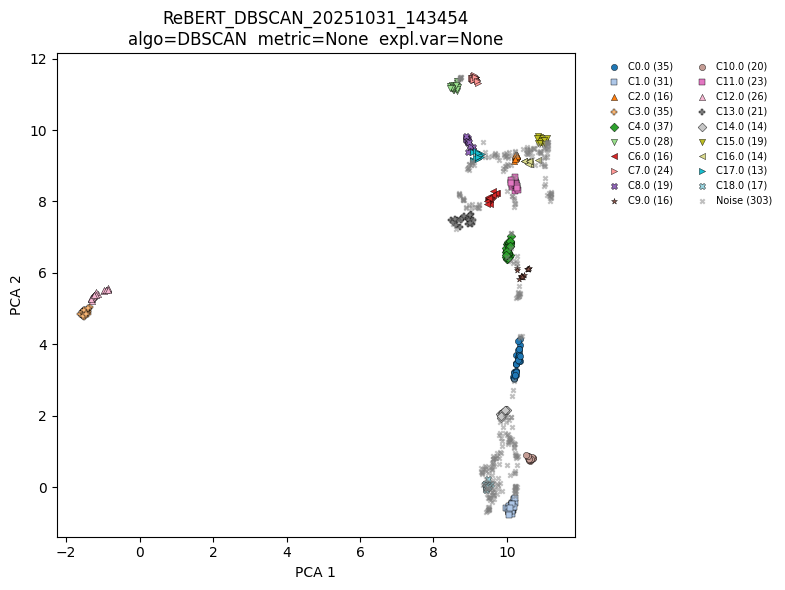

In [84]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from pathlib import Path
import json
import itertools

run_id = "ReBERT_DBSCAN_20251031_143454"
csv = Path("artifacts_without_messages") / f"{run_id}.csv"
meta = Path("artifacts_without_messages") / f"{run_id}.json"

df = pd.read_csv(csv)
with open(meta) as f:
    info = json.load(f)

labels = df["cluster"].values
unique = sorted(np.unique(labels))
clusters = [u for u in unique if u >= 0]
noise_n = int(np.sum(labels == -1))

# ----- color + marker palettes -----
cmap = cm.get_cmap("tab20", len(clusters))  # distinct qualitative colors
markers = itertools.cycle(["o", "s", "^", "P", "D", "v", "<", ">", "X", "*"])  # 10 marker styles

plt.figure(figsize=(8,6))

# ----- plot clusters -----
for idx, cid in enumerate(clusters):
    pts = df[labels == cid]
    color = cmap(idx)
    marker = next(markers)
    plt.scatter(
        pts["x"], pts["y"], 
        s=20, 
        marker=marker, 
        c=[color],
        edgecolor="black", linewidths=0.3,
        label=f"C{cid} ({len(pts)})"
    )

# ----- plot noise -----
if noise_n > 0:
    pts = df[labels == -1]
    plt.scatter(
        pts["x"], pts["y"], 
        s=10, 
        marker="x",
        c="gray", 
        alpha=0.5,
        label=f"Noise ({noise_n})"
    )

# ----- titles and legend -----
title = (
    f"{info.get('run_id', run_id)}\n"
    f"algo={info.get('algorithm')}  metric={info.get('metric')}  "
    f"expl.var={info.get('pca_explained_variance_ratio')}"
)
plt.title(title)
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")

plt.legend(
    bbox_to_anchor=(1.04, 1), loc="upper left",
    ncol=2, frameon=False, fontsize=7, handletextpad=0.4
)
plt.tight_layout()
plt.show()


/var/folders/hd/3r4ph2yd3v17l1p5f3smzm640000gp/T/ipykernel_79759/2949331091.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20", len(clusters))


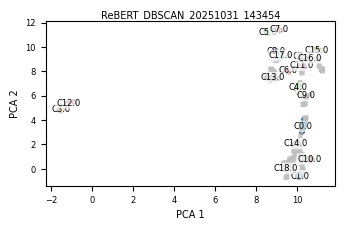

In [85]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.cm import get_cmap

run_id = "ReBERT_DBSCAN_20251031_143454"
root = Path("artifacts_without_messages")
df   = pd.read_csv(root / f"{run_id}.csv")
info = json.loads((root / f"{run_id}.json").read_text())

labels = df["cluster"].to_numpy()
is_noise = labels == -1
clusters = [c for c in np.unique(labels) if c >= 0]

# figure tuned for IEEE single column
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
})
fig, ax = plt.subplots(figsize=(3.35, 2.2))

# palette + markers
cmap = get_cmap("tab20", len(clusters))
markers = ["o","s","^","P","D","v","<",">","X","*"]  # cycles if >10
def m(i): return markers[i % len(markers)]

# clusters
for i, cid in enumerate(clusters):
    pts = df[labels == cid]
    ax.scatter(pts["x"], pts["y"], s=10, c=[cmap(i)], marker=m(i),
               edgecolor="black", linewidths=0.2)

# noise (light gray x)
if is_noise.any():
    pts = df[is_noise]
    ax.scatter(pts["x"], pts["y"], s=8, c="#BFBFBF", marker="x", alpha=0.7)

# annotate cluster centroids with small labels
for i, cid in enumerate(clusters):
    pts = df[labels == cid]
    cx, cy = pts["x"].mean(), pts["y"].mean()
    ax.text(cx, cy, f"C{cid}", fontsize=6, ha="center", va="center",
            color="black", bbox=dict(boxstyle="round,pad=0.15",
            fc="white", ec="none", alpha=0.7))

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_title(f"{run_id}", pad=2)
fig.tight_layout(pad=0.5)
# fig.savefig("ieee_pca_centroids.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/hd/3r4ph2yd3v17l1p5f3smzm640000gp/T/ipykernel_79759/1703958534.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20", len(clusters))


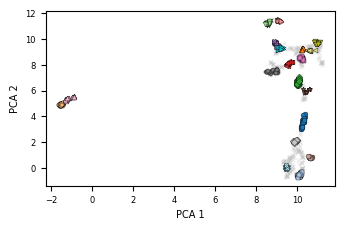

In [ ]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.cm import get_cmap

run_id = "ReBERT_DBSCAN_20251031_143454"
root = Path("artifacts_without_messages")
df   = pd.read_csv(root / f"{run_id}.csv")
info = json.loads((root / f"{run_id}.json").read_text())

labels   = df["cluster"].to_numpy()
is_noise = labels == -1
clusters = [c for c in np.unique(labels) if c >= 0]

# sizes for optional legend trimming (kept large here)
sizes = {c: int((labels == c).sum()) for c in clusters}
clusters_sorted = sorted(clusters, key=lambda c: sizes[c], reverse=True)
TOPK = 50
keep = set(clusters_sorted[:TOPK])

plt.rcParams.update({
    "font.size": 7, "axes.titlesize": 7, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
})
fig, ax = plt.subplots(figsize=(3.35, 2.2))

cmap = get_cmap("tab20", len(clusters))
markers = ["o","s","^","P","D","v","<",">","X","*"]
def m(i): return markers[i % len(markers)]

# --- draw NOISE FIRST (underlay) ---
if is_noise.any():
    pts = df[is_noise]
    ax.scatter(
        pts["x"], pts["y"],
        s=7, c="#BFBFBF", marker="x", alpha=0.45,
        linewidths=0.5, zorder=1, rasterized=True,
        label=f"Noise ({int(is_noise.sum())})"
    )

# --- draw CLUSTERS ON TOP ---
for i, cid in enumerate(clusters):
    pts = df[labels == cid]
    ax.scatter(
        pts["x"], pts["y"],
        s=12, c=[cmap(i)], marker=m(i),
        edgecolor="black", linewidths=0.25,
        zorder=2, rasterized=False,
        label=(f"C{cid} ({sizes[cid]})" if cid in keep else None)
    )

ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2")
# ax.set_title(f"{run_id}", pad=2)

# tiny legend (uncomment if you want it)
# leg = ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1),
#                 frameon=False, fontsize=6, handlelength=1.0, handletextpad=0.3)

fig.tight_layout(pad=0.5)
fig.savefig("ieee_pca_tinylegend.pdf", dpi=200, bbox_inches="tight")
plt.show()


In [124]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D


def plot_ieee_pca_compact(
    run_id: str,
    root_dir: str = "artifacts_without_messages",
    output_path: str | None = None,
    figsize=(3.0, 1.8),
    dpi: int = 300,
    show_noise_legend: bool = False,
    four_borders: bool = True, filename: str = run_id
):
    """
    Ultra-compact PCA cluster plot for IEEE columns.
    - Minimal margins/padding
    - Noise underlay, clusters on top
    - Optional legend showing only the noise marker (inside top-left, darker symbol)
    """
    root = Path(root_dir)
    df   = pd.read_csv(root / f"{run_id}.csv")
    _    = json.loads((root / f"{run_id}.json").read_text())  # meta optional

    labels   = df["cluster"].to_numpy()
    is_noise = labels == -1
    clusters = [c for c in np.unique(labels) if c >= 0]

    # --- compact typography ---
    plt.rcParams.update({
        "font.size": 7,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "savefig.pad_inches": 0.01,
        "figure.constrained_layout.use": False,
    })

    fig, ax = plt.subplots(figsize=figsize)

    # --- draw noise first (underlay) ---
    if is_noise.any():
        pts = df[is_noise]
        ax.scatter(
            pts["x"], pts["y"],
            s=7, c="#C0C0C0", marker="x",   # light gray
            alpha=0.45, linewidths=0.5,
            zorder=1, rasterized=True,
        )

    # --- clusters on top ---
    cmap = get_cmap("tab20", len(clusters))
    markers = ["o", "s", "^", "P", "D", "v", "<", ">", "X", "*"]
    def m(i): return markers[i % len(markers)]
    for i, cid in enumerate(clusters):
        pts = df[labels == cid]
        ax.scatter(
            pts["x"], pts["y"],
            s=12, c=[cmap(i)], marker=m(i),
            edgecolor="black", linewidths=0.25,
            zorder=2, rasterized=False,
        )

    # --- axes labels & ticks ---
    ax.set_xlabel("PCA 1", labelpad=1)
    ax.set_ylabel("PCA 2", labelpad=1)
    ax.tick_params(axis="both", which="both", direction="in", length=2, pad=1)
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(plt.MaxNLocator(4))

    # --- margins and limits ---
    ax.margins(x=0.01, y=0.01)
    eps = 0.02
    xmin, xmax = df["x"].min(), df["x"].max()
    ymin, ymax = df["y"].min(), df["y"].max()
    ax.set_xlim(xmin-(xmax-xmin)*eps, xmax+(xmax-xmin)*eps)
    ax.set_ylim(ymin-(ymax-ymin)*eps, ymax+(ymax-ymin)*eps)

    # --- spines ---
    for side in ("bottom", "left", "top", "right"):
        ax.spines[side].set_visible(four_borders or side in ("bottom", "left"))
        ax.spines[side].set_linewidth(0.6)

    # --- small noise-only legend inside the plot ---
    if show_noise_legend:
        # darker gray marker just for legend visibility
        noise_proxy = Line2D(
            [0], [0],
            color="#606060", marker="x", linestyle="None",
            markersize=4.5, markeredgewidth=1.0, label="Noise"
        )
        ax.legend(
            handles=[noise_proxy],
            loc="upper left",
            frameon=False,
            fontsize=6,
            handlelength=1.0,
            handletextpad=0.3,
            borderpad=0.2,
            labelspacing=0.2,
        )

    # --- layout & save ---
    fig.subplots_adjust(left=0.12, right=0.995, bottom=0.15, top=0.98)
    if output_path is None:
        output_path = root / f"{filename}.pdf"

    pad = 0.02
    plt.rcParams["savefig.pad_inches"] = pad
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight", pad_inches=pad)
    plt.close(fig)
    print(f"[saved] {output_path}")


In [126]:
plot_ieee_pca_compact("ReBERT_DBSCAN_20251031_143454",
                      show_noise_legend=True, four_borders=True, root_dir="artifacts_without_messages", figsize=(2.2, 1.5), filename="ReBERT_DBSCAN_without")

[saved] artifacts_without_messages/ReBERT_DBSCAN_without.pdf


/var/folders/hd/3r4ph2yd3v17l1p5f3smzm640000gp/T/ipykernel_79759/671506097.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20", len(clusters))


In [129]:
plot_ieee_pca_compact("ReBERT_DBSCAN_20251031_144525",
                      show_noise_legend=True, four_borders=True, root_dir="artifacts_with_messages", figsize=(2.2, 1.5), filename="ReBERT_DBSCAN_with")

[saved] artifacts_with_messages/ReBERT_DBSCAN_with.pdf


/var/folders/hd/3r4ph2yd3v17l1p5f3smzm640000gp/T/ipykernel_79759/671506097.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20", len(clusters))


In [127]:
plot_ieee_pca_compact("SmartBert_HDBSCAN_20251031_143415",
                      show_noise_legend=True, four_borders=True, root_dir="artifacts_without_messages", figsize=(2.2, 1.5), filename="SmartBert_HDBSCAN_without")

[saved] artifacts_without_messages/SmartBert_HDBSCAN_without.pdf


/var/folders/hd/3r4ph2yd3v17l1p5f3smzm640000gp/T/ipykernel_79759/671506097.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20", len(clusters))
